# CharXiv Failure Prediction — Final Results

This notebook tells the whole story of the CharXiv failure-prediction project, from the released
annotation database through feature selection, the train and validation setup, the choice of model
family, tuning the final logistic regressions, and the held-out test evaluation. It is the single
source for every table and figure used in the presentation, so nothing here is imported from another
notebook.

The task is to predict whether a vision-language model fails a CharXiv chart-reasoning question. The
positive class is failure, so `y = 1` means the model got the item wrong. We predict for three target
models — `GPT-4o`, `Claude-3-5-Sonnet`, and `GPT-4o-Random` — with a **separate classifier per target**.
`GPT-4o-Random` is a random-answer control that fails about 90 percent of items and is never tuned; its
reasoning-demand signal is near chance by design. The primary key performance indicator is ROC-AUC, and
the two secondary indicators are balanced accuracy and F1, reported per target.

The sealed 200-item test set is scored exactly once, in the final section. That section is gated behind
a flag that is off by default, so a normal run of this notebook never reads the held-out items.

## 1. Setup and how the database is prepared for analysis

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import src.features.preprocessing as P
from src.features.transformers import DEMAND_DIMS
from src.splits.splitters import ItemHoldoutSplit
from src.eval.core import fold_predictions, per_fold_metrics, summarize, evaluate, METRIC_COLS
from src.eval import bootstrap
from src.models import registry, tune, train, interpret
%matplotlib inline

RESULTS = ROOT / "results"
FINAL = RESULTS / "final"; FINAL.mkdir(parents=True, exist_ok=True)
ARTIFACTS = ROOT / "artifacts"; ARTIFACTS.mkdir(parents=True, exist_ok=True)
SEED = 20260618                     # the seed lineage of the fixed 800/200 split
splitter = ItemHoldoutSplit(n_splits=5, n_repeats=3)
TARGETS = P.TARGET_MODELS
REAL = ["GPT-4o", "Claude-3-5-Sonnet"]
CONTROL = "GPT-4o-Random"
print("results/final ->", FINAL)

results/final -> /Users/everett/Documents/GitHub/summer26-ai-faithfulness-in-scientific-reasoning-private/results/final


The released database `charxiv_scoring/annotations_charxiv.db` is the raw material. It holds one
row per chart in the `item` table, the twelve model-agnostic DeLeAn demand annotations per item in the
`annotation` table (each scored 0 to 5 by a verdict-blind subagent), and the pre-graded 0/1 correctness
of every released model in the `model_score` table. No evaluation needs to be run; the correctness is
already recorded.

In [2]:
con = P.connect()
schema = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", con)
counts = {t: pd.read_sql_query(f"SELECT COUNT(*) c FROM {t}", con).c.iloc[0] for t in schema.name}
print("tables and row counts:")
for t, n in counts.items():
    print(f"  {t:16s} {n:>7,}")
print()
print("the 12 DeLeAn demand dimensions (the engineered feature block):")
print(" ", ", ".join(DEMAND_DIMS))

tables and row counts:
  annotation        12,000
  item               1,000
  model_score      195,000
  pass                   1
  sqlite_sequence        1

the 12 DeLeAn demand dimensions (the engineered feature block):
  VL, AS, MCr, MCu, MA, VO, AT, GS, QLl, KNf, QLq, CL


The design matrix turns that database into a modeling table. `make_design_matrix` produces one
row per item over the 800 training items. Each row carries the twelve demand dimensions, the item
metadata (kept only as a baseline), one failure label per target model (`y__<model>`), and the paper id
used to group cross-validation folds. The three classifiers share this feature block and differ only in
which label column they predict. Only the 800 training items are read here; the 200 held-out items are
never loaded in this section.

In [3]:
train_ids, test_ids = P.get_split(con)
df = P.make_design_matrix(con, train_ids)              # one row per item (800 rows)
con.close()

def for_target(t):
    d = df.copy(); d["y"] = d[P.ycol(t)].to_numpy(); return d

print("design matrix:", df.shape, "  (800 train items)")
print("failure label columns:", P.TARGET_YCOLS)
display(df[P.TARGET_YCOLS].mean().round(3).rename("failure_rate").to_frame())
df.head(3)

design matrix: (800, 21)   (800 train items)
failure label columns: ['y__GPT-4o', 'y__Claude-3-5-Sonnet', 'y__GPT-4o-Random']


,failure_rate
y__GPT-4o,0.514
y__Claude-3-5-Sonnet,0.390
y__GPT-4o-Random,0.899


,item_id,paperid,y__GPT-4o,y__Claude-3-5-Sonnet,y__GPT-4o-Random,VL,AS,MCr,MCu,MA,...,AT,GS,QLl,KNf,QLq,CL,category,inst_category,year,groups
0,charxiv_val_1002,2107.11028,1,1,1,1.0,3.0,1.0,2.0,0.0,...,3.0,2.0,1.0,0.0,0.0,0.0,math,2,21,2107.11028
1,charxiv_val_1003,2101.09813,0,1,1,3.0,2.0,1.0,0.0,2.0,...,2.0,0.0,1.0,1.0,1.0,0.0,math,3,21,2101.09813
2,charxiv_val_1007,2105.10044,1,1,1,3.0,3.0,3.0,0.0,0.0,...,2.0,0.0,0.0,1.0,1.0,0.0,math,3,21,2105.10044


## 2. Feature selection: what was kept, dropped, and created

The only engineered features are the twelve DeLeAn demand dimensions. The feature-selection
checkpoint reached two decisions. First, the demand dimension `CL` is dropped because it is
near-constant (about 82 percent zeros), so it carries almost no information. Second, the item metadata
(`category`, `inst_category`, and `year`) is kept only as a cheap baseline and left off the final feature
set, because for the two real models it does not beat the demand dimensions and adds nothing on top of
them. The block below reproduces the decision table.

In [4]:
feature_rows = [{"feature": d, "type": "demand_dim",
                 "decision": "drop" if d == "CL" else "keep",
                 "reason": "near-constant (~82% zeros)" if d == "CL" else "engineered demand dim"}
                for d in DEMAND_DIMS]
feature_rows += [{"feature": c, "type": "item_metadata_baseline", "decision": "drop",
                  "reason": "baseline only; demand dims beat it and it adds ~0 on top"}
                 for c in P.CATEGORICAL]
feature_decisions = pd.DataFrame(feature_rows)
feature_decisions.to_csv(FINAL / "feature_decisions.csv", index=False)
feature_decisions

,feature,type,decision,reason
0,VL,demand_dim,keep,engineered demand dim
1,AS,demand_dim,keep,engineered demand dim
2,MCr,demand_dim,keep,engineered demand dim
3,MCu,demand_dim,keep,engineered demand dim
4,MA,demand_dim,keep,engineered demand dim
5,VO,demand_dim,keep,engineered demand dim
6,AT,demand_dim,keep,engineered demand dim
7,GS,demand_dim,keep,engineered demand dim
8,QLl,demand_dim,keep,engineered demand dim
9,KNf,demand_dim,keep,engineered demand dim


The central feature-engineering question was whether the demand dimensions add predictive value
over a cheap metadata-only baseline, for each target. The ablation below re-evaluates each target's
classifier under three feature configurations with paper-grouped cross-validation. For the two real
models the demand dimensions are the large lift over metadata; for the random control they add nothing,
because a random answer's success is governed by the answer format, not the reasoning demand.

In [5]:
ablation_configs = {
    "Metadata (baseline)": lambda: P.build_preprocessor(include_demand_dims=False, include_metadata=True),
    "Demand dims":         lambda: P.build_preprocessor(include_demand_dims=True,  include_metadata=False),
    "Demand + metadata":   lambda: P.build_preprocessor(include_demand_dims=True,  include_metadata=True),
}
rows = []
for t in TARGETS:
    for name, make_pre_cfg in ablation_configs.items():
        s, _, _ = evaluate(for_target(t), make_pre_cfg, registry.logistic, splitter)
        rows.append({"target": t, "config": name, "roc_auc": round(float(s["roc_auc"]), 4),
                     "roc_auc_sd": round(float(s["roc_auc_sd"]), 4)})
feature_ablation = pd.DataFrame(rows)
feature_ablation.to_csv(FINAL / "feature_ablation.csv", index=False)
display(feature_ablation.pivot(index="config", columns="target", values="roc_auc")
        .reindex(list(ablation_configs))[TARGETS].round(4))

target,GPT-4o,Claude-3-5-Sonnet,GPT-4o-Random
config,,,
Metadata (baseline),0.5279,0.5359,0.7267
Demand dims,0.6758,0.6275,0.5799
Demand + metadata,0.6678,0.6170,0.7237


## 3. Train and validation setup

The data is split once into 800 training items and 200 held-out test items, with a fixed seed so
the split is stable across runs. The 200 test items stay sealed until the final section. Model selection
and tuning use only the 800 training items.

Within the training items, cross-validation is grouped by paper id. A single CharXiv paper can
contribute several figures, so grouping by paper guarantees that no paper (and therefore no figure)
appears in both the training and validation side of a fold. Folds are also stratified on the failure
label so the failure rate is balanced, and the whole scheme is repeated three times to give a mean and
standard deviation across folds. The failure base rate per target model is shown below.

In [6]:
print("train items:", len(train_ids), " | sealed test items:", len(test_ids), " | seed:", SEED)
print("cross-validation folds:", splitter.get_n_splits(df), "(5 folds x 3 repeats), grouped by paperid")
print()
print("failure rate by target model (training items):")
print(df[P.TARGET_YCOLS].mean().round(3).to_string())

train items: 800  | sealed test items: 200  | seed: 20260618
cross-validation folds: 15 (5 folds x 3 repeats), grouped by paperid

failure rate by target model (training items):
y__GPT-4o               0.514
y__Claude-3-5-Sonnet    0.390
y__GPT-4o-Random        0.899


## 4. Choice of model family

The model family was chosen in the earlier modeling notebooks. The baselines notebook established
trivial and simple reference points per target, and the experiments notebook tuned four families (a
regularized logistic regression, a random forest, a histogram gradient boosting model, and XGBoost)
under honest nested paper-grouped cross-validation for the two real targets. The tuned ensembles did not
beat the linear model: their cross-validated ROC-AUC clustered around 0.68 for `GPT-4o` and 0.63 for
`Claude-3-5-Sonnet`, and the self-regularizing tree models drifted toward very shallow trees, which
points to a feature-to-signal ceiling rather than a model-choice problem. A later bootstrap of the
training set and a TabPFN flexibility check both left that reading standing.

We therefore keep logistic regression for every target: it reaches the best cross-validated ROC-AUC of
any family, it is the simplest and most interpretable strong model, and no more complex family justified
its added cost. `GPT-4o-Random` is fit with the default logistic regression and never tuned, because
there is no reasoning signal to optimize. The remaining work, below, is to tune the logistic regression
for the two real targets and to fit the three final models.

## 5. Train and tune the logistic regression

Tuning uses nested, paper-grouped cross-validation for the two real targets. The hyperparameters
are chosen in an inner paper-grouped loop, and the reported ROC-AUC is measured on outer folds the tuner
never saw, so there is no tuning-on-test leakage. The search covers the regularization choice directly:
no penalty, ridge (L2), lasso (L1), or elastic net, each over a short strength grid. Including the
unpenalized fit as an explicit option lets the data decide whether any regularization helps at all. The
control keeps the default logistic regression.

In [7]:
LOGISTIC_GRID = registry.LOGISTIC_REGULARIZED_GRID + [{"clf__penalty": [None]}]
make_pre = lambda: P.build_preprocessor()          # the 12 demand dims (CL dropped)

def tuned_factory(modal_params):
    params = {k.replace("clf__", ""): v for k, v in tune.modal_params_dict({"modal_best_params": modal_params}).items()}
    def factory():
        est = registry.logistic_regularized(); est.set_params(**params); return est
    return factory

final_factory, tuning_rows = {}, []
for t in REAL:
    res = tune.nested_cv_auc(for_target(t), make_pre, registry.logistic_regularized(),
                             LOGISTIC_GRID, splitter, inner_k=3, seed=0)
    final_factory[t] = tuned_factory(res["modal_best_params"])
    tuning_rows.append({"target": t, "roc_auc": round(res["roc_auc"], 4),
                        "roc_auc_sd": round(res["roc_auc_sd"], 4),
                        "modal_best_params": res["modal_best_params"]})
    print(f"{t:18s} nested CV ROC-AUC {res['roc_auc']:.4f}  modal {res['modal_best_params']}")
final_factory[CONTROL] = registry.logistic
s_ctrl, _, _ = evaluate(for_target(CONTROL), make_pre, registry.logistic, splitter)
tuning_rows.append({"target": CONTROL, "roc_auc": round(float(s_ctrl["roc_auc"]), 4),
                    "roc_auc_sd": round(float(s_ctrl["roc_auc_sd"]), 4),
                    "modal_best_params": "default logistic (untuned control)"})
tuning_table = pd.DataFrame(tuning_rows)
tuning_table.to_csv(FINAL / "logistic_tuning.csv", index=False)
tuning_table

GPT-4o             nested CV ROC-AUC 0.6739  modal {'clf__C': 0.1, 'clf__penalty': 'l2'}


Claude-3-5-Sonnet  nested CV ROC-AUC 0.6272  modal {'clf__C': 0.1, 'clf__penalty': 'l2'}


,target,roc_auc,roc_auc_sd,modal_best_params
0,GPT-4o,0.6739,0.0325,"{'clf__C': 0.1, 'clf__penalty': 'l2'}"
1,Claude-3-5-Sonnet,0.6272,0.0473,"{'clf__C': 0.1, 'clf__penalty': 'l2'}"
2,GPT-4o-Random,0.5799,0.0528,default logistic (untuned control)


Tuning the hyperparameters fixes how each classifier ranks items, but the two secondary indicators,
balanced accuracy and F1, also depend on the probability cutoff that turns a predicted failure
probability into a hard failure or non-failure decision. The default cutoff of 0.5 is rarely the one
that maximizes balanced accuracy. For the two real classifiers we therefore tune the decision threshold
with `TunedThresholdClassifierCV`, which searches only the cutoff that maximizes balanced accuracy in a
paper-grouped inner cross-validation. This changes the threshold alone and leaves the previously chosen
hyperparameters and the fitted coefficients untouched. Each real classifier is tuned separately, and the
random control keeps the default cutoff of 0.5. The tuned thresholds are applied only when the sealed
test set is scored, so they never touch the training cross-validation results above. ROC-AUC is a
ranking measure and is unaffected by the threshold.

In [8]:
# Tune the decision threshold to maximize balanced accuracy, for the two real classifiers only.
import json
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TunedThresholdClassifierCV

thresholds = {}
for t in REAL:
    d_t = for_target(t).reset_index(drop=True)
    base = Pipeline([("pre", make_pre()), ("clf", final_factory[t]())])
    cv_folds = tune._inner_folds(d_t, inner_k=5, seed=0)          # paper-grouped inner folds
    ttc = TunedThresholdClassifierCV(
        base, scoring="balanced_accuracy",
        response_method="predict_proba",     # keep the threshold on the P(failure) scale
        cv=cv_folds,
    ).fit(d_t, d_t["y"].to_numpy())
    thresholds[t] = float(ttc.best_threshold_)
    print(f"{t:18s} tuned decision threshold {thresholds[t]:.4f}")
thresholds[CONTROL] = 0.5                                          # untuned negative control

threshold_table = pd.DataFrame([{"target": t, "decision_threshold": round(thresholds[t], 4),
                                 "tuned": t in REAL} for t in TARGETS])
threshold_table.to_csv(FINAL / "decision_thresholds.csv", index=False)
(ARTIFACTS / "final_thresholds.json").write_text(json.dumps({t: thresholds[t] for t in TARGETS}, indent=2))
threshold_table

GPT-4o             tuned decision threshold 0.5193


Claude-3-5-Sonnet  tuned decision threshold 0.4011


,target,decision_threshold,tuned
0,GPT-4o,0.5193,True
1,Claude-3-5-Sonnet,0.4011,True
2,GPT-4o-Random,0.5000,False


## 6. Cross-validated performance, interpretability, and the serialized models

The KPI table below reports the cross-validated performance of each target's final classifier on
the training items across all three key performance indicators. These are honest paper-grouped folds, so
they estimate how each model generalizes to charts from unseen papers. The two real models sit near 0.68
and 0.63; the random control sits near chance, exactly as the negative control should.

In [9]:
rows = []
PRED = {}
for t in TARGETS:
    summary, per_fold, pred = evaluate(for_target(t), make_pre, final_factory[t], splitter)
    PRED[t] = pred
    rows.append({"target": t,
                 "roc_auc": round(float(summary["roc_auc"]), 4), "roc_auc_sd": round(float(summary["roc_auc_sd"]), 4),
                 "bal_acc": round(float(summary["bal_acc"]), 4), "f1": round(float(summary["f1"]), 4)})
cv_kpis = pd.DataFrame(rows)
cv_kpis.to_csv(FINAL / "cv_kpis.csv", index=False)
cv_kpis.set_index("target")

,roc_auc,roc_auc_sd,bal_acc,f1
target,,,,
GPT-4o,0.6759,0.0331,0.6312,0.6499
Claude-3-5-Sonnet,0.6282,0.0490,0.5670,0.3793
GPT-4o-Random,0.5799,0.0528,0.5000,0.9467


The two figures below use single-repeat out-of-fold predictions so each training item appears
once. The ROC curve summarizes the ranking quality behind the ROC-AUC for each target, and the
calibration curve shows how closely the predicted failure probabilities match observed failure rates.

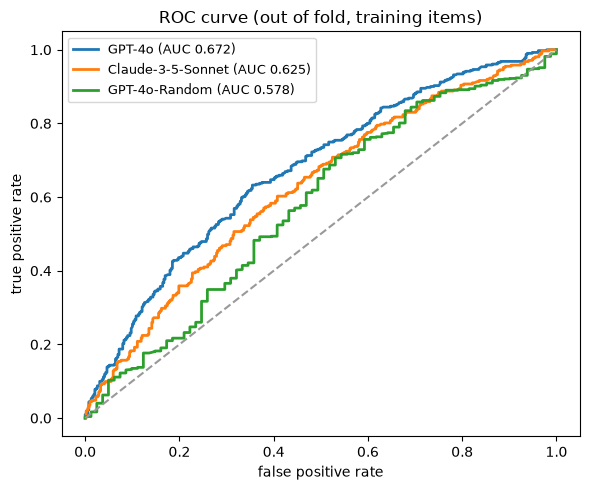

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve
oof = {t: fold_predictions(for_target(t), make_pre, final_factory[t],
                           ItemHoldoutSplit(n_splits=5, n_repeats=1)) for t in TARGETS}

fig, ax = plt.subplots(figsize=(6, 5))
for t in TARGETS:
    g = oof[t]; fpr, tpr, _ = roc_curve(g.y_true, g.y_prob)
    ax.plot(fpr, tpr, lw=2, label=f"{t} (AUC {roc_auc_score(g.y_true, g.y_prob):.3f})")
ax.plot([0, 1], [0, 1], "--", c="0.6")
ax.set(xlabel="false positive rate", ylabel="true positive rate",
       title="ROC curve (out of fold, training items)")
ax.legend(fontsize=9); fig.tight_layout()
fig.savefig(FINAL / "roc_curve_oof.png", dpi=130); plt.show()

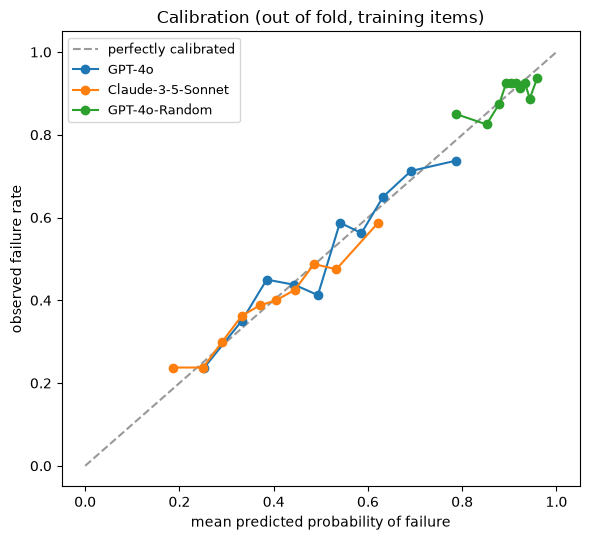

In [11]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot([0, 1], [0, 1], "--", c="0.6", label="perfectly calibrated")
for t in TARGETS:
    g = oof[t]
    frac_pos, mean_pred = calibration_curve(g.y_true, g.y_prob, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=t)
ax.set(xlabel="mean predicted probability of failure", ylabel="observed failure rate",
       title="Calibration (out of fold, training items)")
ax.legend(fontsize=9); fig.tight_layout()
fig.savefig(FINAL / "calibration_oof.png", dpi=130); plt.show()

Because the final models are linear, their coefficients are directly interpretable as the signed
contribution of each demand dimension to the log-odds of failure. Each pipeline is refit on all 800
training items before reading its coefficients. A permutation-importance table complements the in-sample
coefficients with a held-out view, scored by ROC-AUC. Rather than reading it off a single held-out
slice, we compute it on every paper-grouped held-out slice of the cross-validation (five folds times
three repeats, so fifteen slices) and average the per-feature importances, so the reported bar is the
mean drop in ROC-AUC across held-out slices and the error bar is the standard deviation of those
per-slice means.

In [12]:
final_models = {t: train.fit_final(for_target(t), make_pre, final_factory[t]) for t in TARGETS}
coef_frames = []
for t in TARGETS:
    cf = interpret.logistic_coefficients(final_models[t]).round(4); cf.insert(0, "target", t)
    coef_frames.append(cf)
coefs = pd.concat(coef_frames, ignore_index=True)
coefs.to_csv(FINAL / "logistic_coefficients.csv", index=False)
for t in REAL:
    print(f"=== {t}: largest-magnitude coefficients (log-odds of failure) ===")
    display(coefs[coefs.target == t].head(6).set_index("feature")[["coef", "abs_coef"]])

=== GPT-4o: largest-magnitude coefficients (log-odds of failure) ===


,coef,abs_coef
feature,,
demand__MCu,0.4178,0.4178
demand__QLq,-0.2577,0.2577
demand__GS,-0.2566,0.2566
demand__AS,0.2184,0.2184
demand__VO,0.1876,0.1876
demand__AT,0.1330,0.1330


=== Claude-3-5-Sonnet: largest-magnitude coefficients (log-odds of failure) ===


,coef,abs_coef
feature,,
demand__MCu,0.2658,0.2658
demand__QLq,-0.2573,0.2573
demand__AS,0.2180,0.2180
demand__GS,-0.1534,0.1534
demand__MCr,0.1075,0.1075
demand__MA,0.1071,0.1071


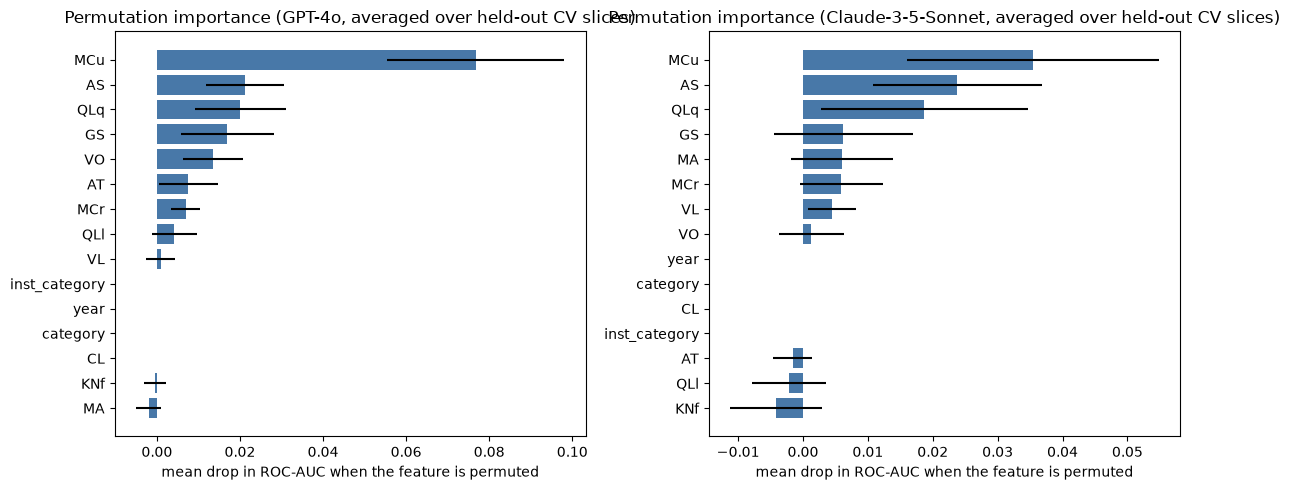

In [13]:
# Permutation importance is averaged over every held-out slice of the paper-grouped cross-validation
# (5 folds x 3 repeats = 15 slices) rather than read off a single slice. For each slice the tuned
# pipeline is refit on the slice's training rows and permutation importance is measured on its held-out
# rows; the per-slice means are then averaged per feature, and the error bar is the standard deviation
# of those per-slice means, so it reflects variation across held-out slices.
pi_splitter = ItemHoldoutSplit(n_splits=5, n_repeats=3)
perm_frames = []
for t in TARGETS:
    d_t = for_target(t)
    slice_means = []
    for tr_idx, va_idx in pi_splitter.split(d_t):
        pi_pipe = train.fit_final(d_t.iloc[tr_idx], make_pre, final_factory[t])
        pm = interpret.permutation_importance_table(pi_pipe, d_t.iloc[va_idx], n_repeats=20, seed=0)
        slice_means.append(pm.set_index("feature")["importance_mean"])
    slice_df = pd.concat(slice_means, axis=1)                     # rows = feature, columns = slice
    agg = pd.DataFrame({"target": t, "feature": slice_df.index,
                        "importance_mean": slice_df.mean(axis=1).to_numpy(),
                        "importance_sd": slice_df.std(axis=1, ddof=0).to_numpy()})
    perm_frames.append(agg.reset_index(drop=True))
perm = pd.concat(perm_frames, ignore_index=True).round(4)
perm.to_csv(FINAL / "permutation_importance.csv", index=False)

# One panel per real classifier. Every candidate feature is shown (all 12 demand dims and the 3
# metadata columns), sorted ascending so the most important feature sits at the top, matching the
# layout of the permutation-importance chart in notebook 17.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, t in zip(axes, REAL):
    p = perm[perm.target == t].sort_values("importance_mean")
    ax.barh(p.feature, p.importance_mean, xerr=p.importance_sd, color="#4878a8")
    ax.set(xlabel="mean drop in ROC-AUC when the feature is permuted",
           title=f"Permutation importance ({t}, averaged over held-out CV slices)")
fig.tight_layout(); fig.savefig(FINAL / "permutation_importance.png", dpi=130); plt.show()

The three refit pipelines are serialized together as the final model, a dictionary keyed by target
model. Fitting uses only the 800 training items, so saving the models does not touch the sealed test
set.

In [14]:
model_path = train.save(final_models, ARTIFACTS / "final_model.joblib")
print("saved three per-target models ->", model_path)
print("targets:", list(final_models))

saved three per-target models -> /Users/everett/Documents/GitHub/summer26-ai-faithfulness-in-scientific-reasoning-private/artifacts/final_model.joblib
targets: ['GPT-4o', 'Claude-3-5-Sonnet', 'GPT-4o-Random']


## 7. Held-out test evaluation (sealed until the model family is agreed)

This section scores the final models on the sealed 200-item test set exactly once. It is gated
behind the `CHARXIV_EVAL_TEST` environment variable, which is off by default, so a normal run of this
notebook skips every cell here and never reads the held-out items. When the model family is agreed, set
`CHARXIV_EVAL_TEST=1` and run the notebook once to fill in the test tables and figures.

Because the 800/200 split is item-level, a few multi-figure papers place one figure in the training
split and another in the test split. Those test items share a paper with a training item, which is the
one paper-level leakage path at the train/test boundary, so we remove them and report the KPIs only on
the clean cohort rather than on all 200 items. The two real classifiers are scored at the balanced
accuracy thresholds tuned earlier, and the random control stays at the default cutoff of 0.5. A
100-resample item-level bootstrap of the clean cohort then gives a 95 percent confidence interval for
each KPI next to the single-test-set value.

In [15]:
EVALUATE_TEST = os.environ.get("CHARXIV_EVAL_TEST", "0") == "1"
if EVALUATE_TEST:
    print("CHARXIV_EVAL_TEST=1 : the sealed test set will be scored below.")
else:
    print("CHARXIV_EVAL_TEST is off : the sealed test set is NOT read. "
          "Set CHARXIV_EVAL_TEST=1 to run this section.")

CHARXIV_EVAL_TEST=1 : the sealed test set will be scored below.


In [16]:
if EVALUATE_TEST:
    con = P.connect()
    test_df = P.make_design_matrix(con, test_ids)          # first read of the held-out items
    paper_map = pd.read_sql_query("SELECT item_id, paperid FROM item", con).set_index("item_id").paperid
    con.close()
    final_loaded = train.load(ARTIFACTS / "final_model.joblib")
    thr = json.loads((ARTIFACTS / "final_thresholds.json").read_text())

    # The 800/200 split is item-level, so a few multi-figure papers contribute one figure to the
    # training split and another to the test split. Those test items share a paper with a training
    # item, which is the one paper-level leakage path at the train/test boundary. We remove them and
    # report the KPIs only on the clean cohort rather than on all 200 items.
    train_papers = set(paper_map.loc[list(train_ids)])
    straddle = set(paper_map.loc[list(test_ids)]) & train_papers
    keep = ~test_df["paperid"].isin(straddle).to_numpy()
    print(f"straddling papers: {len(straddle)}  |  test items removed: {int((~keep).sum())}  "
          f"|  clean test items kept: {int(keep.sum())}")

    rows = []
    for t in TARGETS:
        y_true = test_df[P.ycol(t)].to_numpy()[keep]
        y_prob = final_loaded[t].predict_proba(test_df)[:, 1][keep]
        pt = bootstrap.kpis(y_true, y_prob, threshold=thr[t])       # tuned cutoff for the real models
        rows.append({"target": t, "decision_threshold": round(thr[t], 4),
                     **{k: round(float(v), 4) for k, v in pt.items()}})
    test_kpis = pd.DataFrame(rows)
    test_kpis.to_csv(FINAL / "test_kpis.csv", index=False)
    display(test_kpis.set_index("target"))
else:
    print("sealed section skipped: single-test-set KPIs not computed.")

straddling papers: 6  |  test items removed: 6  |  clean test items kept: 194


,decision_threshold,roc_auc,bal_acc,f1
target,,,,
GPT-4o,0.5193,0.5533,0.5258,0.6114
Claude-3-5-Sonnet,0.4011,0.6940,0.6256,0.6022
GPT-4o-Random,0.5000,0.5880,0.5000,0.9252


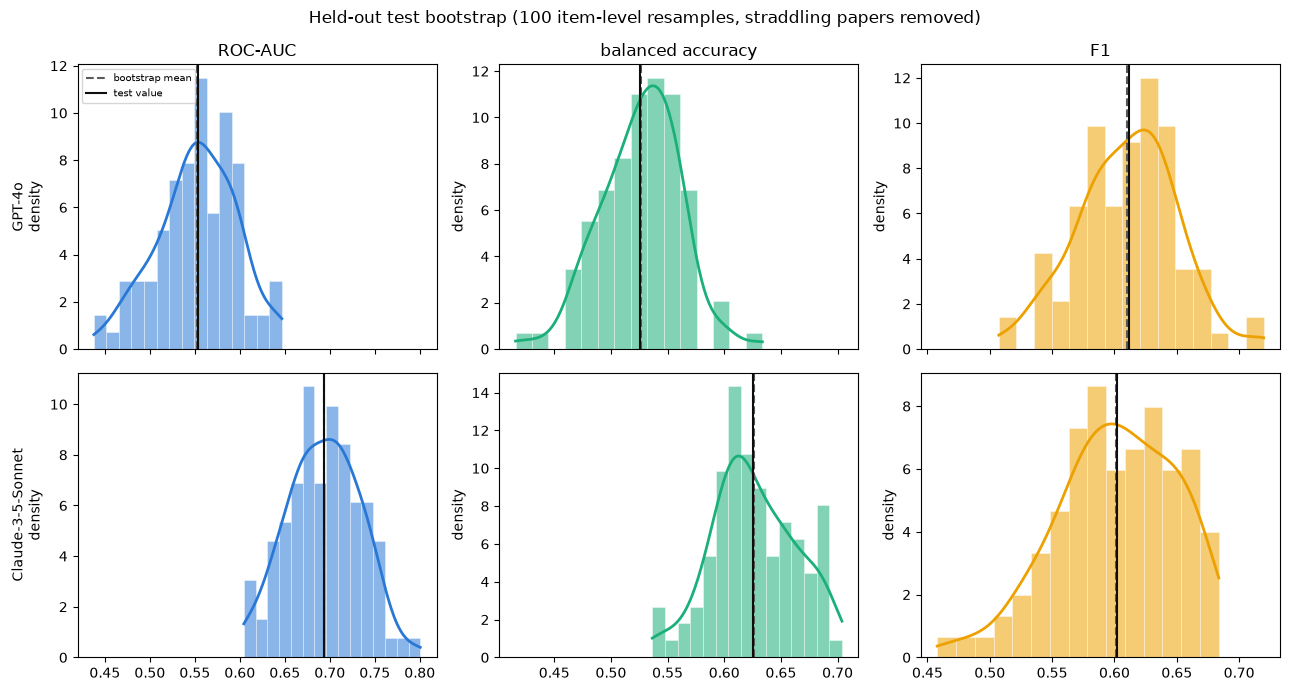

point  boot_mean  boot_sd   ci_lo   ci_hi
target            kpi                                                
GPT-4o            roc_auc  0.5533     0.5528   0.0443  0.4678  0.6392
                  bal_acc  0.5258     0.5264   0.0350  0.4650  0.5957
                  f1       0.6114     0.6101   0.0394  0.5395  0.6763
Claude-3-5-Sonnet roc_auc  0.6940     0.6931   0.0403  0.6116  0.7610
                  bal_acc  0.6256     0.6262   0.0370  0.5491  0.6906
                  f1       0.6022     0.6014   0.0478  0.5010  0.6736
GPT-4o-Random     roc_auc  0.5880     0.5789   0.0530  0.4845  0.6756
                  bal_acc  0.5000     0.5000   0.0000  0.5000  0.5000
                  f1       0.9252     0.9260   0.0139  0.9008  0.9557

In [17]:
if EVALUATE_TEST:
    from scipy import stats

    KPI_COLOR = {"roc_auc": "#2a78d6", "bal_acc": "#1baf7a", "f1": "#eda100"}   # one hue per KPI
    KPI_TITLE = {"roc_auc": "ROC-AUC", "bal_acc": "balanced accuracy", "f1": "F1"}

    # Bootstrap the clean cohort (straddling papers removed) with the tuned thresholds.
    df_keep = test_df[keep].reset_index(drop=True)
    boot_all, ci_rows, point = [], [], {}
    for t in TARGETS:
        y_true = test_df[P.ycol(t)].to_numpy()[keep]
        y_prob = final_loaded[t].predict_proba(test_df)[:, 1][keep]
        b = bootstrap.bootstrap_kpis(df_keep, y_true, y_prob, n_boot=100, seed=SEED, threshold=thr[t])
        b.insert(0, "target", t); boot_all.append(b)
        point[t] = bootstrap.kpis(y_true, y_prob, threshold=thr[t])            # non-bootstrap test value
        ci = bootstrap.percentile_ci(b, point[t]); ci.insert(0, "target", t); ci_rows.append(ci)
    ball = pd.concat(boot_all, ignore_index=True)
    ball.to_csv(FINAL / "bootstrap_test_kpis.csv", index=False)
    ci_all = pd.concat(ci_rows, ignore_index=True)
    ci_all.to_csv(FINAL / "bootstrap_ci.csv", index=False)

    # Per-KPI density histograms, one row per real classifier. Each KPI keeps the same colour across
    # both rows; the dashed line marks the bootstrap mean and the solid line the non-bootstrap test
    # value, and a kernel-density curve traces the approximate sampling distribution.
    fig, axes = plt.subplots(len(REAL), len(METRIC_COLS), figsize=(13, 7), sharex="col")
    for i, t in enumerate(REAL):
        for j, cc in enumerate(METRIC_COLS):
            ax = axes[i, j]
            vals = ball.loc[ball.target == t, cc].to_numpy()
            vals = vals[~np.isnan(vals)]                                       # drop single-class resamples
            ax.hist(vals, bins=15, density=True, color=KPI_COLOR[cc], alpha=0.55,
                    edgecolor="white", linewidth=0.5)
            try:                                                              # KDE, normal fallback if degenerate
                if vals.std() < 1e-9:
                    raise ValueError
                grid = np.linspace(vals.min(), vals.max(), 200)
                ax.plot(grid, stats.gaussian_kde(vals)(grid), color=KPI_COLOR[cc], lw=2)
            except Exception:
                sd = vals.std() or 1e-6
                grid = np.linspace(vals.min() - 3 * sd, vals.max() + 3 * sd, 200)
                ax.plot(grid, stats.norm.pdf(grid, vals.mean(), sd), color=KPI_COLOR[cc], lw=2)
            ax.axvline(vals.mean(), color="0.35", ls="--", lw=1.5, label="bootstrap mean")
            ax.axvline(point[t][cc], color="0.05", ls="-", lw=1.5, label="test value")
            if i == 0:
                ax.set_title(KPI_TITLE[cc])
            ax.set_ylabel(f"{t}\ndensity" if j == 0 else "density")
    axes[0, 0].legend(fontsize=7, loc="upper left")
    fig.suptitle("Held-out test bootstrap (100 item-level resamples, straddling papers removed)")
    fig.tight_layout(); fig.savefig(FINAL / "bootstrap_hist.png", dpi=130); plt.show()
    display(ci_all.set_index(["target", "kpi"]))
else:
    print("sealed section skipped: test-set bootstrap not computed.")

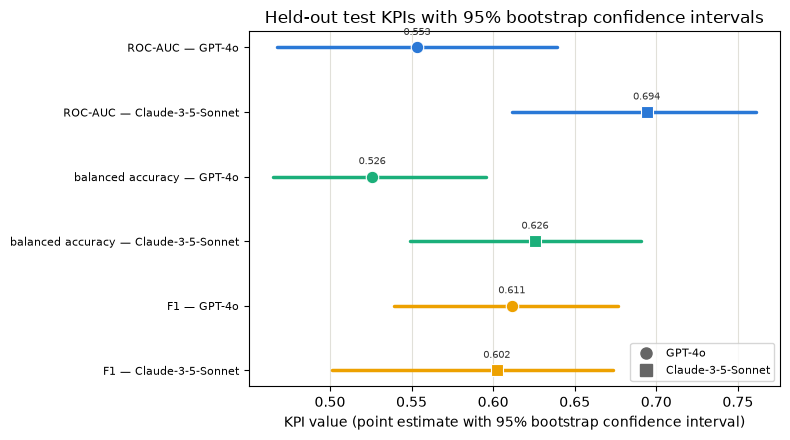

In [18]:
if EVALUATE_TEST:
    from matplotlib.lines import Line2D

    # 95 percent bootstrap confidence intervals for all three KPIs, per real classifier. Rows are
    # grouped by KPI and coloured with the same scheme as the histograms above; the marker shape
    # distinguishes the two models.
    order = [(cc, t) for cc in METRIC_COLS for t in REAL]        # group rows by KPI
    marker = {REAL[0]: "o", REAL[1]: "s"}
    fig, ax = plt.subplots(figsize=(8, 4.5))
    yticks, ylabels = [], []
    for k, (cc, t) in enumerate(order):
        y = len(order) - k                                       # first KPI at the top
        r = ci_all[(ci_all.target == t) & (ci_all.kpi == cc)].iloc[0]
        ax.plot([r.ci_lo, r.ci_hi], [y, y], color=KPI_COLOR[cc], lw=2.5, solid_capstyle="round", zorder=2)
        ax.plot(r.point, y, marker=marker[t], color=KPI_COLOR[cc], ms=9, zorder=3,
                markeredgecolor="white", markeredgewidth=0.8)
        ax.annotate(f"{r.point:.3f}", (r.point, y), textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=7, color="0.2")
        yticks.append(y); ylabels.append(f"{KPI_TITLE[cc]} — {t}")
    ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=8)
    ax.set(xlabel="KPI value (point estimate with 95% bootstrap confidence interval)",
           title="Held-out test KPIs with 95% bootstrap confidence intervals")
    handles = [Line2D([0], [0], marker=marker[t], color="0.4", ls="", ms=8, label=t) for t in REAL]
    ax.legend(handles=handles, fontsize=8, loc="lower right")
    ax.grid(axis="x", color="#e1e0d9", lw=0.8); ax.set_axisbelow(True)
    fig.tight_layout(); fig.savefig(FINAL / "bootstrap_ci.png", dpi=130); plt.show()
else:
    print("sealed section skipped: bootstrap CI chart not computed.")

## 8. Limitations and next steps

A few limitations are worth stating plainly. The 800/200 split is item-level rather than
paper-grouped, so a small number of papers have figures on both sides; the final section reports the
test KPIs both on all items and with those papers removed so the effect is visible. The test set is
small at 200 items, which is why the final KPIs come with bootstrap confidence intervals rather than
single numbers. The cross-validated ROC-AUC for the real models sits near 0.68 and 0.63 across every
model family we tried, which suggests a feature-to-signal ceiling: the twelve demand dimensions are the
large lift over the metadata baseline, but the demand-only signal is modest. The `GPT-4o-Random` control
confirms the demand dimensions measure reasoning demand rather than answer-guessability, since they do
not predict a random answer.

Natural next steps are to enrich the feature set beyond the demand annotations (for example
chart-structural or question-level features), to extend the target set beyond the three models, and to
give the flexible models a full cross-validated, hardware-accelerated treatment before concluding that
added complexity cannot help. The sealed-test numbers in the final section remain pending the agreement
on the final model family.

## 9. Post-hoc audit: train and test balance and split sensitivity

The held-out test results in the previous section are worth interrogating. `GPT-4o` scored a lower
ROC-AUC on the sealed test set than in cross-validation, while `Claude-3-5-Sonnet` scored higher. This
section asks whether the fixed 800/200 split is responsible. It runs two checks, and because both read
the sealed test items, both are gated behind the same `CHARXIV_EVAL_TEST` flag used above, so a normal
training run never reads them.

The first check is a balance audit. It asks, for each quantity, whether the training and test items
differ by more than sampling noise would explain. The twelve demand dimensions are compared with a
Mann-Whitney U test because they are ordinal scores from 0 to 5; the three metadata columns with a
chi-square test of independence between the category and the split; and each target's failure rate with
a chi-square test on the two-by-two failure-by-split table. Because eighteen tests are run at once, a
Holm-Bonferroni adjustment is added so that no single nominal p-value is over-read.

In [19]:
if EVALUATE_TEST:
    from scipy import stats

    # Both checks read the sealed test items, so build fresh train and test design matrices here.
    con = P.connect()
    audit_train = P.make_design_matrix(con, train_ids)
    audit_test = P.make_design_matrix(con, test_ids)
    con.close()

    audit_rows = []
    # (a) demand dimensions: Mann-Whitney U on the ordinal 0-5 demand scores, train vs test.
    for d in DEMAND_DIMS:
        a, b = audit_train[d].to_numpy(), audit_test[d].to_numpy()
        U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        audit_rows.append({"quantity": d, "kind": "demand_dim", "test": "Mann-Whitney U",
                           "train_summary": round(float(a.mean()), 3), "test_summary": round(float(b.mean()), 3),
                           "statistic": round(float(U), 2), "p_value": float(p)})
    # (b) metadata: chi-square test of independence between split membership and each category
    #     (train_summary / test_summary here report the number of distinct levels on each side).
    for c in P.CATEGORICAL:
        combined = pd.concat([audit_train[[c]].assign(split="train"),
                              audit_test[[c]].assign(split="test")], ignore_index=True)
        ct = pd.crosstab(combined[c], combined["split"])
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        audit_rows.append({"quantity": c, "kind": "metadata", "test": f"chi-square (dof {dof})",
                           "train_summary": float(audit_train[c].nunique()),
                           "test_summary": float(audit_test[c].nunique()),
                           "statistic": round(float(chi2), 2), "p_value": float(p)})
    # (c) failure rates: chi-square on the 2x2 failure-by-split table, per target.
    for t in TARGETS:
        yc = P.ycol(t)
        a, b = audit_train[yc].to_numpy(), audit_test[yc].to_numpy()
        ct = np.array([[a.sum(), len(a) - a.sum()], [b.sum(), len(b) - b.sum()]])
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        audit_rows.append({"quantity": f"failure_rate:{t}", "kind": "failure_rate", "test": "chi-square 2x2",
                           "train_summary": round(float(a.mean()), 3), "test_summary": round(float(b.mean()), 3),
                           "statistic": round(float(chi2), 2), "p_value": float(p)})

    balance = pd.DataFrame(audit_rows)
    # Holm-Bonferroni step-down adjustment across all tests run here, so no single p-value is over-read.
    p_raw = balance["p_value"].to_numpy()
    order = np.argsort(p_raw); m = len(p_raw); adj = np.empty(m); running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, min((m - rank) * p_raw[idx], 1.0))
        adj[idx] = running
    balance["p_holm"] = adj.round(4)
    balance["p_value"] = balance["p_value"].round(4)
    balance["sig_holm_0.05"] = balance["p_holm"] < 0.05
    balance.to_csv(FINAL / "balance_audit.csv", index=False)
    display(balance.set_index("quantity"))
    print(f"significant after Holm adjustment: {int(balance['sig_holm_0.05'].sum())} of {m} tests")
else:
    print("post-hoc audit skipped: set CHARXIV_EVAL_TEST=1 to run it.")

,kind,test,train_summary,test_summary,statistic,p_value,p_holm,sig_holm_0.05
quantity,,,,,,,,
VL,demand_dim,Mann-Whitney U,2.281,2.340,76850.00,0.3278,1.0000,False
AS,demand_dim,Mann-Whitney U,2.645,2.725,74389.50,0.0633,1.0000,False
MCr,demand_dim,Mann-Whitney U,1.644,1.715,75068.00,0.1361,1.0000,False
MCu,demand_dim,Mann-Whitney U,0.670,0.715,77118.50,0.3766,1.0000,False
MA,demand_dim,Mann-Whitney U,2.399,2.325,82708.00,0.4455,1.0000,False
VO,demand_dim,Mann-Whitney U,1.170,1.195,78000.00,0.4056,1.0000,False
AT,demand_dim,Mann-Whitney U,2.565,2.610,77282.00,0.3889,1.0000,False
GS,demand_dim,Mann-Whitney U,0.810,0.665,85672.00,0.0721,1.0000,False
QLl,demand_dim,Mann-Whitney U,1.004,0.970,81877.00,0.5253,1.0000,False


significant after Holm adjustment: 0 of 18 tests


The second check asks whether the original split was unusual by resampling. All 1,000 items are pooled
and split into a roughly 800/200 train and test partition 100 times, grouped by paper id so that no
paper straddles a split. For each split the tuned logistic regression is refit on the training items,
with its hyperparameters fixed at the values chosen once on the original train split and only the
coefficients (and, for the two real targets, the balanced-accuracy decision threshold) refit per split,
and the three key performance indicators are recorded on that split's test items. These resamples are
paper-grouped, whereas the cached original split is item-level, so the comparison is regime-approximate.
The table below summarizes the 100 splits, and the original split is then recomputed under the identical
protocol and placed within that distribution by a percentile rank.

In [20]:
if EVALUATE_TEST:
    from sklearn.model_selection import GroupShuffleSplit

    # Pool all 1,000 items; refit the tuned logistic on 100 random paper-grouped 80/20 splits.
    con = P.connect()
    all_ids = sorted(set(train_ids) | set(test_ids))
    full_df = P.make_design_matrix(con, all_ids)
    con.close()
    print("pooled design matrix:", full_df.shape)

    def fit_and_score(tr, te):
        """Fit each target on rows tr and score KPIs on rows te; real targets re-tune the threshold."""
        out = {}
        for t in TARGETS:
            d_tr = full_df.iloc[tr].copy(); d_tr["y"] = d_tr[P.ycol(t)].to_numpy()
            d_te = full_df.iloc[te]
            pipe = train.fit_final(d_tr, make_pre, final_factory[t])
            y_true = d_te[P.ycol(t)].to_numpy()
            y_prob = pipe.predict_proba(d_te)[:, 1]
            if t in REAL:                                   # re-tune threshold on this split's train rows
                base = Pipeline([("pre", make_pre()), ("clf", final_factory[t]())])
                cv_folds = tune._inner_folds(d_tr.reset_index(drop=True), inner_k=5, seed=0)
                ttc = TunedThresholdClassifierCV(base, scoring="balanced_accuracy",
                                                 response_method="predict_proba", cv=cv_folds
                                                 ).fit(d_tr, d_tr["y"].to_numpy())
                thr_t = float(ttc.best_threshold_)
            else:
                thr_t = 0.5                                 # untuned negative control
            out[t] = bootstrap.kpis(y_true, y_prob, threshold=thr_t)
        return out

    gss = GroupShuffleSplit(n_splits=100, train_size=0.8, random_state=SEED)
    split_rows = []
    for s, (tr, te) in enumerate(gss.split(full_df, groups=full_df["paperid"].to_numpy())):
        res = fit_and_score(tr, te)
        for t in TARGETS:
            split_rows.append({"split": s, "target": t, "n_test": int(len(te)), **res[t]})
    splits100 = pd.DataFrame(split_rows)
    splits100.to_csv(FINAL / "split_sensitivity_100.csv", index=False)

    # Summary across the 100 splits, per target per KPI.
    stat_funcs = {"mean": np.nanmean, "std": np.nanstd, "min": np.nanmin, "max": np.nanmax,
                  "p2.5": lambda x: np.nanpercentile(x, 2.5), "p97.5": lambda x: np.nanpercentile(x, 97.5)}
    summ_rows = []
    for t in TARGETS:
        g = splits100[splits100.target == t]
        for cc in METRIC_COLS:
            vals = g[cc].to_numpy()
            row = {"target": t, "kpi": cc}
            row.update({name: round(float(fn(vals)), 4) for name, fn in stat_funcs.items()})
            summ_rows.append(row)
    split_summary = pd.DataFrame(summ_rows)
    split_summary.to_csv(FINAL / "split_sensitivity_summary.csv", index=False)
    print("100 paper-grouped splits, KPI summary per target:")
    display(split_summary.set_index(["target", "kpi"]))

    # The original split, recomputed under the identical fit-and-threshold protocol, and its percentile
    # rank within the 100-split distribution. This scores all 200 original test items, whereas the
    # sealed section removed 6 straddling items, so its ROC-AUC differs slightly from that table.
    posmap = {iid: k for k, iid in enumerate(full_df["item_id"].tolist())}
    tr_pos = np.array([posmap[i] for i in sorted(train_ids) if i in posmap])
    te_pos = np.array([posmap[i] for i in sorted(test_ids) if i in posmap])
    orig = fit_and_score(tr_pos, te_pos)
    orig_rows = []
    for t in TARGETS:
        for cc in METRIC_COLS:
            v = float(orig[t][cc])
            dist = splits100.loc[splits100.target == t, cc].to_numpy()
            dist = dist[~np.isnan(dist)]
            orig_rows.append({"target": t, "kpi": cc, "original": round(v, 4),
                              "pct_of_100_below": round(100.0 * float((dist < v).mean()), 1)})
    split_original = pd.DataFrame(orig_rows)
    split_original.to_csv(FINAL / "split_sensitivity_original.csv", index=False)
    print("original split under the identical protocol, and its percentile within the 100 splits:")
    display(split_original.set_index(["target", "kpi"]))
else:
    print("post-hoc audit skipped: set CHARXIV_EVAL_TEST=1 to run it.")

pooled design matrix: (1000, 21)


100 paper-grouped splits, KPI summary per target:


mean     std     min     max    p2.5   p97.5
target            kpi                                                    
GPT-4o            roc_auc  0.6500  0.0319  0.5877  0.7457  0.5901  0.7178
                  bal_acc  0.6025  0.0275  0.5348  0.6620  0.5539  0.6549
                  f1       0.6023  0.0506  0.4944  0.7120  0.5072  0.6936
Claude-3-5-Sonnet roc_auc  0.6471  0.0380  0.5179  0.7235  0.5627  0.7109
                  bal_acc  0.5969  0.0309  0.5058  0.6648  0.5358  0.6588
                  f1       0.5147  0.0581  0.3077  0.6359  0.3945  0.6065
GPT-4o-Random     roc_auc  0.5753  0.0626  0.3723  0.7893  0.4670  0.6840
                  bal_acc  0.4999  0.0004  0.4971  0.5000  0.5000  0.5000
                  f1       0.9431  0.0113  0.9151  0.9668  0.9212  0.9627

original split under the identical protocol, and its percentile within the 100 splits:


original  pct_of_100_below
target            kpi                                
GPT-4o            roc_auc    0.5539               0.0
                  bal_acc    0.5288               0.0
                  f1         0.6160              58.0
Claude-3-5-Sonnet roc_auc    0.6925              89.0
                  bal_acc    0.6209              76.0
                  f1         0.5969              96.0
GPT-4o-Random     roc_auc    0.5893              58.0
                  bal_acc    0.5000               2.0
                  f1         0.9276              11.0

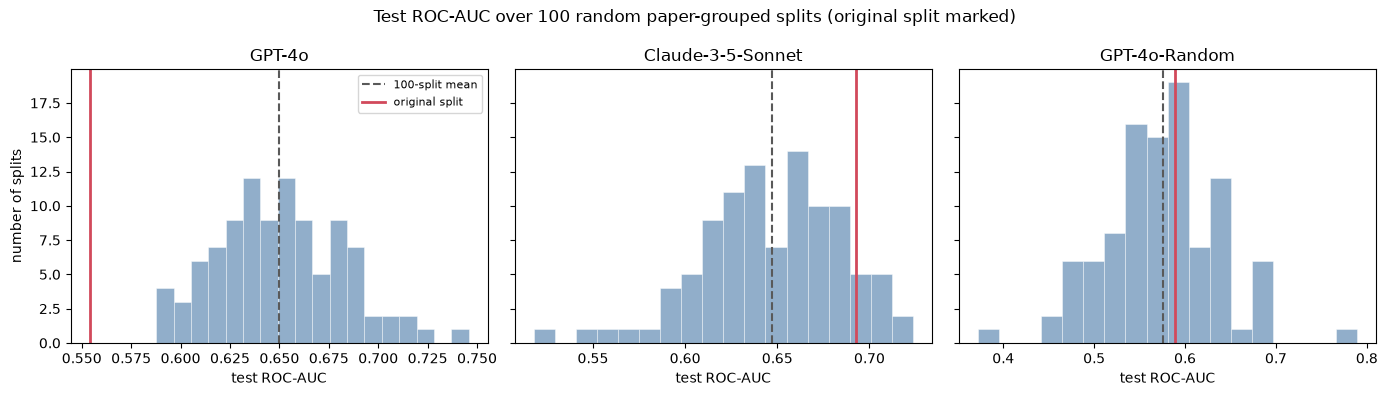

In [21]:
if EVALUATE_TEST:
    # Test ROC-AUC distribution over the 100 paper-grouped splits, per target, with the original split
    # (identical protocol) marked. ROC-AUC is threshold-free, so it is the cleanest split-to-split view.
    orig_auc = {t: float(orig[t]["roc_auc"]) for t in TARGETS}
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ax, t in zip(axes, TARGETS):
        vals = splits100.loc[splits100.target == t, "roc_auc"].to_numpy()
        vals = vals[~np.isnan(vals)]
        ax.hist(vals, bins=18, color="#4878a8", alpha=0.6, edgecolor="white", linewidth=0.5)
        ax.axvline(float(np.mean(vals)), color="0.35", ls="--", lw=1.5, label="100-split mean")
        ax.axvline(orig_auc[t], color="#d1495b", ls="-", lw=2, label="original split")
        ax.set(xlabel="test ROC-AUC", title=t)
    axes[0].set_ylabel("number of splits"); axes[0].legend(fontsize=8)
    fig.suptitle("Test ROC-AUC over 100 random paper-grouped splits (original split marked)")
    fig.tight_layout(); fig.savefig(FINAL / "split_sensitivity_hist.png", dpi=130); plt.show()
else:
    print("post-hoc audit skipped: split-sensitivity histogram not drawn.")